# DDPM From Scratch — FashionMNIST

**Denoising Diffusion Probabilistic Models (DDPM)** implementation from scratch using PyTorch.

### Key Improvements in this Version:
- ✅ Lower learning rate (`2e-4`) for stable training
- ✅ Gradient clipping (`max_norm=1.0`) to prevent loss spikes
- ✅ **EMA (Exponential Moving Average)** of model weights for better sample quality
- ✅ GroupNorm with `num_groups=8` (instead of instance norm)
- ✅ 50 training epochs for better convergence
- ✅ Loss curve plotting & denoising process visualization

**Dataset:** FashionMNIST (28×28 grayscale, 60K training images)

In [1]:
# Imports
import torch
import torchvision
import math
import copy
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils, datasets
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda:0


In [3]:
# Hyperparameters
T = 1000              # Number of diffusion timesteps
img_size = 28          # Image resolution
batch_size = 128       # Batch size
epochs = 50            # Training epochs
lr = 2e-4              # Learning rate (lower for stability)
base_channels = 64     # Base channel count for U-Net
ema_decay = 0.9999     # EMA decay rate
grad_clip = 1.0        # Gradient clipping max norm

## 1. Dataset — FashionMNIST

We normalize images to `[-1, 1]` range (standard for diffusion models).

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 197kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.72MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 25.6MB/s]


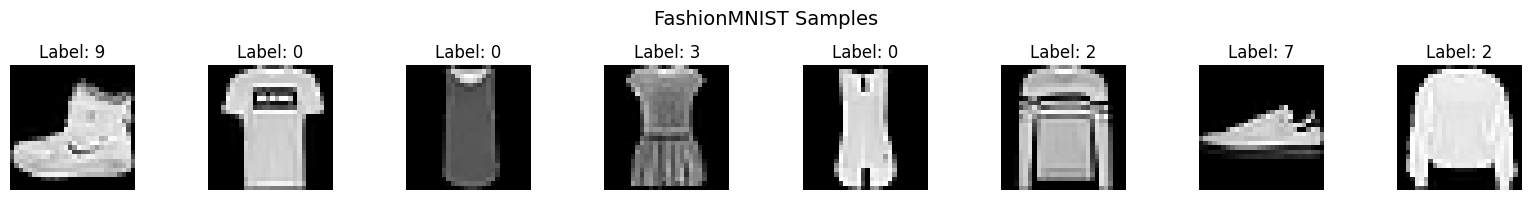

In [4]:
# Dataset
transform_data = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 2 - 1)  # Scale to [-1, 1]
])

train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform_data
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, drop_last=True)

# Visualize some training samples
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i, (img, label) in enumerate(train_dataset):
    if i >= 8: break
    axes[i].imshow((img[0] + 1) / 2, cmap='gray')
    axes[i].set_title(f'Label: {label}')
    axes[i].axis('off')
plt.suptitle('FashionMNIST Samples', fontsize=14)
plt.tight_layout()
plt.show()

## 2. Forward Diffusion Process

The forward process gradually adds Gaussian noise to an image over `T` timesteps:

$$q(x_t | x_0) = \mathcal{N}(x_t; \sqrt{\bar{\alpha}_t} \, x_0, \, (1 - \bar{\alpha}_t) \, \mathbf{I})$$

Where $\bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s$ and $\alpha_t = 1 - \beta_t$.

Using the **reparameterization trick**:
$$x_t = \sqrt{\bar{\alpha}_t} \, x_0 + \sqrt{1 - \bar{\alpha}_t} \, \epsilon \quad \text{where } \epsilon \sim \mathcal{N}(0, \mathbf{I})$$

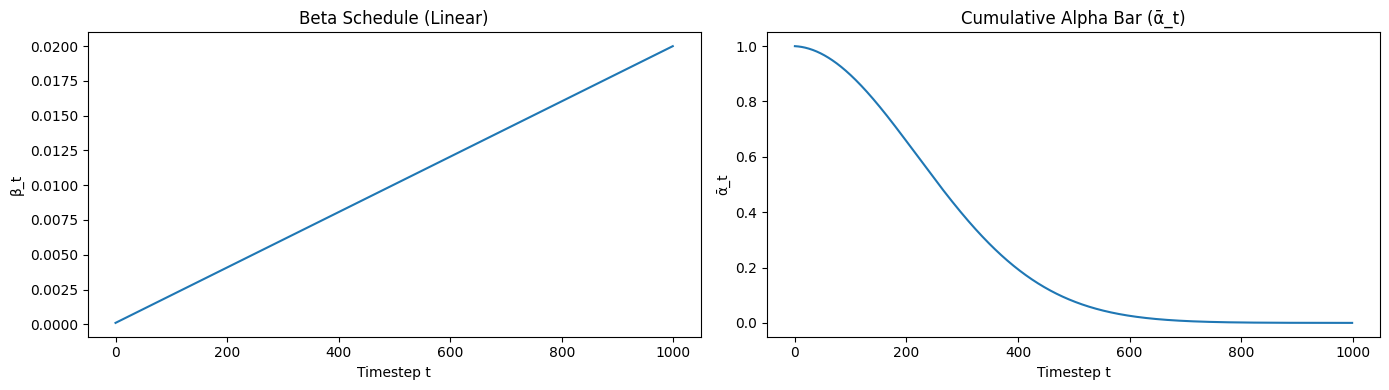

In [5]:
# Forward diffusion parameters (linear beta schedule)
betas = torch.linspace(1e-4, 0.02, T)
alphas = 1 - betas
alphas_bars = torch.cumprod(alphas, dim=0)

# Move to device
alphas_bars = alphas_bars.to(device)

# Plot the noise schedule
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(betas.numpy())
ax1.set_title('Beta Schedule (Linear)')
ax1.set_xlabel('Timestep t')
ax1.set_ylabel('β_t')

ax2.plot(alphas_bars.cpu().numpy())
ax2.set_title('Cumulative Alpha Bar (ᾱ_t)')
ax2.set_xlabel('Timestep t')
ax2.set_ylabel('ᾱ_t')
plt.tight_layout()
plt.show()

In [6]:
def forward_diffusion(x0, t):
    """Apply forward diffusion: x_t = sqrt(alpha_bar_t) * x0 + sqrt(1-alpha_bar_t) * noise"""
    noise = torch.randn_like(x0)
    sqrt_ab = torch.sqrt(alphas_bars[t])[:, None, None, None]
    sqrt_one_minus_ab = torch.sqrt(1 - alphas_bars[t])[:, None, None, None]
    xt = sqrt_ab * x0 + sqrt_one_minus_ab * noise
    return xt, noise

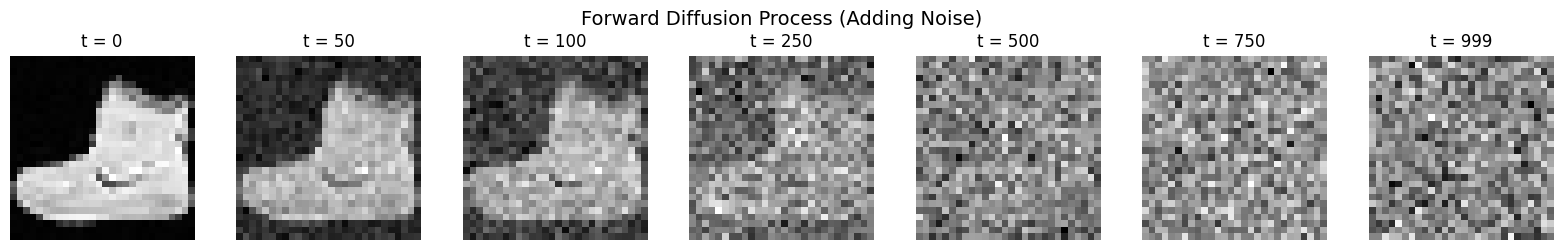

In [9]:
# Visualize the forward diffusion process
sample_img = train_dataset[0][0].unsqueeze(0).to(device)  # (1, 1, 28, 28)
timesteps_to_show = [0, 50, 100, 250, 500, 750, 999]

fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(16, 2.5))
for i, t_val in enumerate(timesteps_to_show):
    t_tensor = torch.tensor([t_val]).to(device)
    noisy, _ = forward_diffusion(sample_img, t_tensor)
    axes[i].imshow((noisy[0, 0].cpu() + 1) / 2, cmap='gray')
    axes[i].set_title(f't = {t_val}')
    axes[i].axis('off')
plt.suptitle('Forward Diffusion Process (Adding Noise)', fontsize=14)
plt.tight_layout()
plt.show()

## 3. U-Net Noise Predictor

The U-Net takes a noisy image `x_t` and timestep `t`, and predicts the noise `ε` that was added.

**Architecture:**
- Sinusoidal time embeddings → MLP projection
- Encoder: 2 residual blocks with downsampling (AvgPool2d)
- Bottleneck: ResBlock → Self-Attention → ResBlock
- Decoder: 2 residual blocks with upsampling + skip connections
- GroupNorm(8) for normalization, SiLU activation

In [10]:
class TimeEmbedding(nn.Module):
    """Sinusoidal time embedding (same as Transformer positional encoding)."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / half)
        args = t[:, None] * freqs[None, :]
        output = torch.cat((torch.sin(args), torch.cos(args)), dim=-1)
        return output

In [11]:
class ResidualBlock(nn.Module):
    """Pre-activation residual block with time conditioning."""
    def __init__(self, in_channels, out_channels, time_emb_dim):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.norm2 = nn.GroupNorm(8, out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.time_mlp = nn.Linear(time_emb_dim, out_channels)
        self.skip = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()

    def forward(self, x, t):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.time_mlp(t)[:, :, None, None]  # Add time embedding
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)  # Residual connection

In [12]:
class AttentionBlock(nn.Module):
    """Self-attention block for spatial feature refinement."""
    def __init__(self, in_channels):
        super().__init__()
        self.norm = nn.GroupNorm(8, in_channels)
        self.q = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        self.k = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        self.v = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        self.proj = nn.Conv2d(in_channels, in_channels, kernel_size=1)

    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x)
        q = self.q(h).reshape(B, C, H * W)
        k = self.k(h).reshape(B, C, H * W)
        v = self.v(h).reshape(B, C, H * W)
        attn = torch.softmax(q.transpose(1, 2) @ k / math.sqrt(C), dim=-1)
        h = (attn @ v.transpose(1, 2)).transpose(1, 2).reshape(B, C, H, W)
        return x + self.proj(h)

In [13]:
class DDPMUNet(nn.Module):
    """U-Net architecture for DDPM noise prediction."""
    def __init__(self):
        super().__init__()
        time_emb_dim = base_channels * 4

        # Time embedding MLP
        self.time_mlp = nn.Sequential(
            TimeEmbedding(base_channels),
            nn.Linear(base_channels, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim)
        )

        # Initial convolution
        self.conv0 = nn.Conv2d(1, base_channels, kernel_size=3, padding=1)

        # Encoder
        self.down1 = ResidualBlock(base_channels, base_channels, time_emb_dim)
        self.down2 = ResidualBlock(base_channels, base_channels * 2, time_emb_dim)
        self.pool = nn.AvgPool2d(2)

        # Bottleneck
        self.mid1 = ResidualBlock(base_channels * 2, base_channels * 2, time_emb_dim)
        self.attn = AttentionBlock(base_channels * 2)
        self.mid2 = ResidualBlock(base_channels * 2, base_channels * 2, time_emb_dim)

        # Decoder
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')
        self.up1 = ResidualBlock(base_channels * 4, base_channels * 2, time_emb_dim)  # concat skip
        self.up2 = ResidualBlock(base_channels * 3, base_channels, time_emb_dim)      # concat skip

        # Output
        self.conv_out = nn.Conv2d(base_channels, 1, kernel_size=3, padding=1)

    def forward(self, x, t):
        t = self.time_mlp(t.float())

        x = self.conv0(x)                     # (B, 64,  28, 28)

        # Encoder
        s1 = self.down1(x, t)                 # (B, 64,  28, 28)
        s2 = self.down2(self.pool(s1), t)     # (B, 128, 14, 14)

        # Bottleneck
        h = self.pool(s2)                     # (B, 128,  7,  7)
        h = self.mid1(h, t)
        h = self.attn(h)
        h = self.mid2(h, t)

        # Decoder
        h = self.upsample(h)                  # (B, 128, 14, 14)
        h = torch.cat([h, s2], dim=1)         # (B, 256, 14, 14)
        h = self.up1(h, t)                    # (B, 128, 14, 14)

        h = self.upsample(h)                  # (B, 128, 28, 28)
        h = torch.cat([h, s1], dim=1)         # (B, 192, 28, 28)
        h = self.up2(h, t)                    # (B, 64,  28, 28)

        return self.conv_out(h)               # (B, 1,   28, 28)

## 4. Exponential Moving Average (EMA)

EMA maintains a smoothed copy of model weights for sampling, reducing noise in generated outputs:
$$\theta_{\text{EMA}} \leftarrow \lambda \, \theta_{\text{EMA}} + (1 - \lambda) \, \theta$$

where λ = 0.9999 (decay rate).

In [14]:
class EMA:
    """Exponential Moving Average of model parameters for better sampling."""
    def __init__(self, model, decay=0.9999):
        self.decay = decay
        self.shadow = copy.deepcopy(model)
        self.shadow.eval()
        for p in self.shadow.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        for s_param, m_param in zip(self.shadow.parameters(), model.parameters()):
            s_param.data.mul_(self.decay).add_(m_param.data, alpha=1 - self.decay)

    def forward(self, *args, **kwargs):
        return self.shadow(*args, **kwargs)

    def __call__(self, *args, **kwargs):
        return self.forward(*args, **kwargs)

In [15]:
# Initialize model, optimizer, and EMA
model = DDPMUNet().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
ema = EMA(model, decay=ema_decay)

# Print model parameter count
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

Total parameters: 1,846,785


## 5. Training

The model is trained to predict the noise `ε` added during forward diffusion:
$$\mathcal{L} = \mathbb{E}_{x_0, \epsilon, t} \left[ \| \epsilon - \epsilon_\theta(x_t, t) \|^2 \right]$$

In [16]:
# Training loop
losses = []

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for x, _ in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}'):
        x = x.to(device)
        t = torch.randint(0, T, (x.shape[0],)).to(device)

        optimizer.zero_grad()
        xt, noise = forward_diffusion(x, t)
        noise_predicted = model(xt, t)
        loss = F.mse_loss(noise_predicted, noise)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)  # Gradient clipping
        optimizer.step()
        ema.update(model)  # Update EMA weights

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    losses.append(avg_loss)
    print(f'Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.6f}')

Epoch 1/50: 100%|██████████| 468/468 [00:39<00:00, 11.87it/s]


Epoch 1/50 | Loss: 0.081497


Epoch 2/50: 100%|██████████| 468/468 [00:38<00:00, 12.05it/s]


Epoch 2/50 | Loss: 0.049708


Epoch 3/50: 100%|██████████| 468/468 [00:41<00:00, 11.29it/s]


...

Epoch 48/50 | Loss: 0.036501


Epoch 49/50: 100%|██████████| 468/468 [00:41<00:00, 11.19it/s]


Epoch 49/50 | Loss: 0.035949


Epoch 50/50: 100%|██████████| 468/468 [00:41<00:00, 11.30it/s]

Epoch 50/50 | Loss: 0.035943


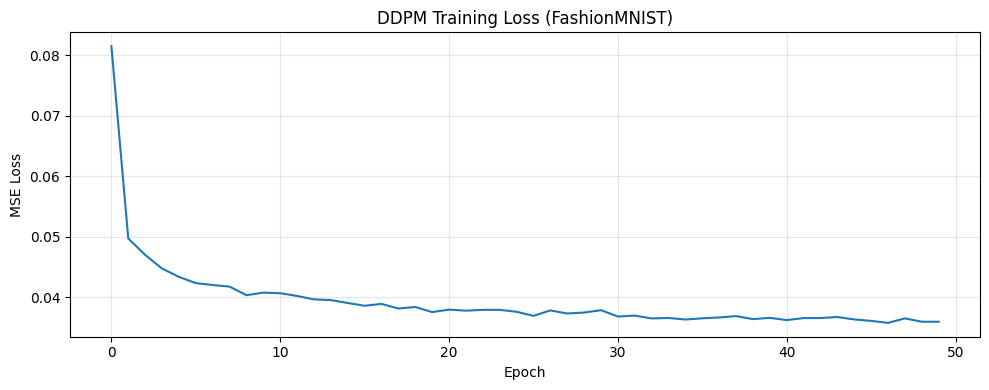

In [17]:
# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(losses, linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('DDPM Training Loss (FashionMNIST)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Sampling (Reverse Diffusion)

Generate images by iteratively denoising from pure Gaussian noise:
$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}} \left( x_t - \frac{1 - \alpha_t}{\sqrt{1 - \bar{\alpha}_t}} \epsilon_\theta(x_t, t) \right) + \sqrt{\beta_t} \, z$$

We use the **EMA model** for sampling to get smoother, higher-quality results.

In [18]:
@torch.no_grad()
def sample_ddpm(model_fn, n=16, return_intermediates=False):
    """Sample from DDPM using reverse diffusion."""
    x = torch.randn((n, 1, img_size, img_size)).to(device)
    intermediates = []

    for t_val in reversed(range(0, T)):
        t_batch = torch.full((n,), t_val, device=device)
        eps = model_fn(x, t_batch)

        alpha = alphas[t_val].to(device)
        alpha_bar = alphas_bars[t_val].to(device)
        beta = betas[t_val].to(device)

        if t_val > 0:
            z = torch.randn_like(x)
        else:
            z = torch.zeros_like(x)

        x = (1 / torch.sqrt(alpha)) * (x - ((1 - alpha) / torch.sqrt(1 - alpha_bar)) * eps) + torch.sqrt(beta) * z

        if return_intermediates and t_val % (T // 10) == 0:
            intermediates.append(x.clone())

    if return_intermediates:
        return x, intermediates
    return x

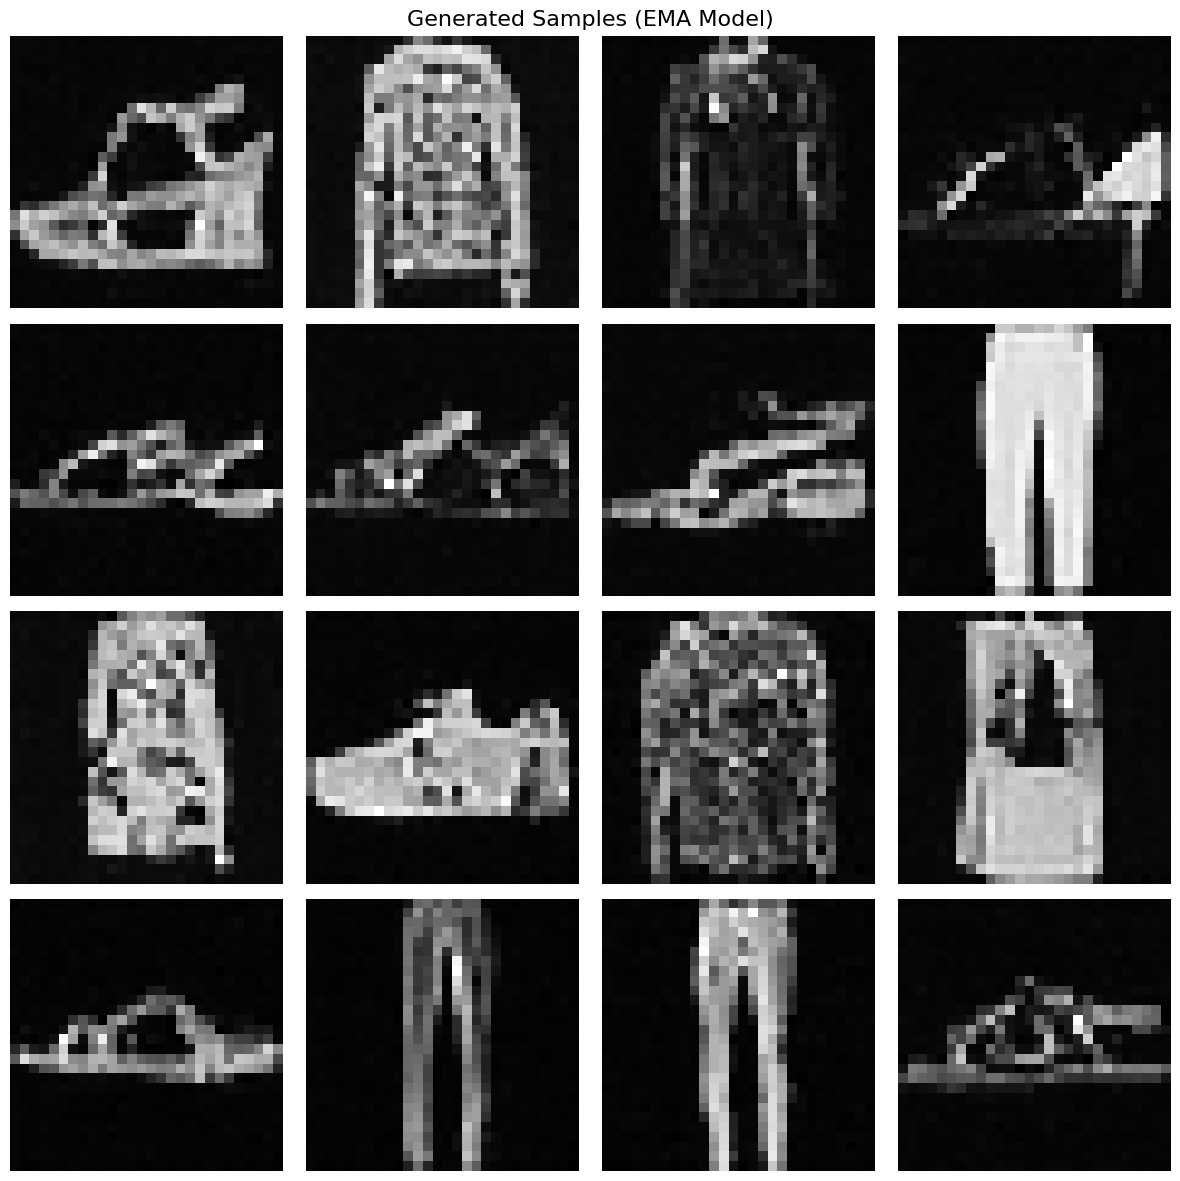

In [19]:
# Generate samples using EMA model
ema.shadow.eval()
samples = sample_ddpm(ema, n=16)
samples = (samples + 1) / 2  # Scale back to [0, 1]

plt.figure(figsize=(12, 12))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(samples[i, 0].cpu(), cmap='gray')
    plt.axis('off')
plt.suptitle('Generated Samples (EMA Model)', fontsize=16)
plt.tight_layout()
plt.show()

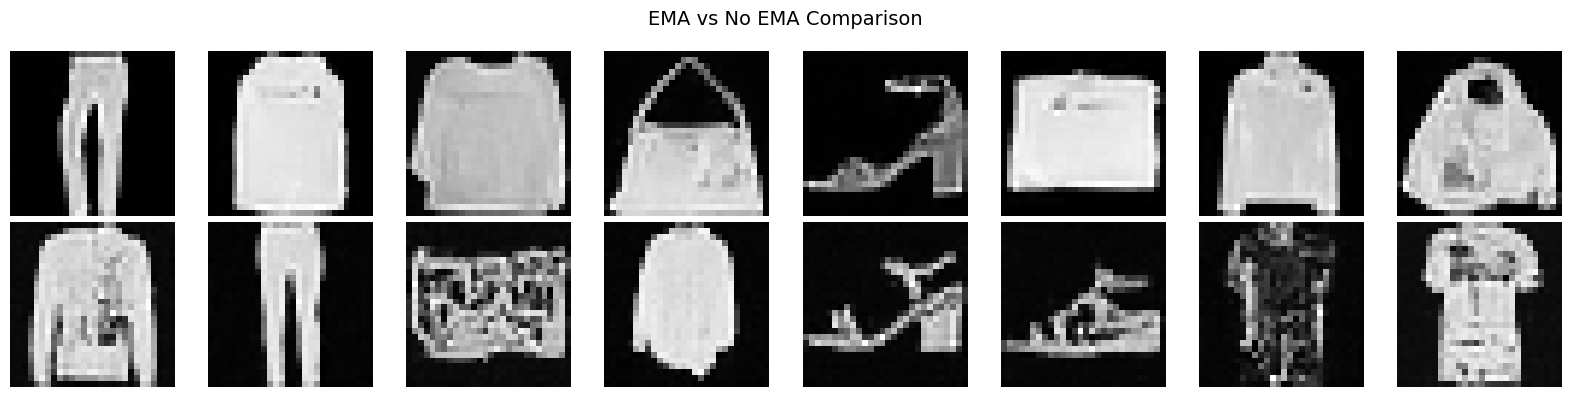

In [20]:
# Compare: EMA vs Regular Model
model.eval()
samples_no_ema = sample_ddpm(model, n=8)
samples_no_ema = (samples_no_ema + 1) / 2

ema.shadow.eval()
samples_ema = sample_ddpm(ema, n=8)
samples_ema = (samples_ema + 1) / 2

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(samples_no_ema[i, 0].cpu(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(samples_ema[i, 0].cpu(), cmap='gray')
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('No EMA', fontsize=12)
axes[1, 0].set_ylabel('With EMA', fontsize=12)
plt.suptitle('EMA vs No EMA Comparison', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Visualize the Denoising Process

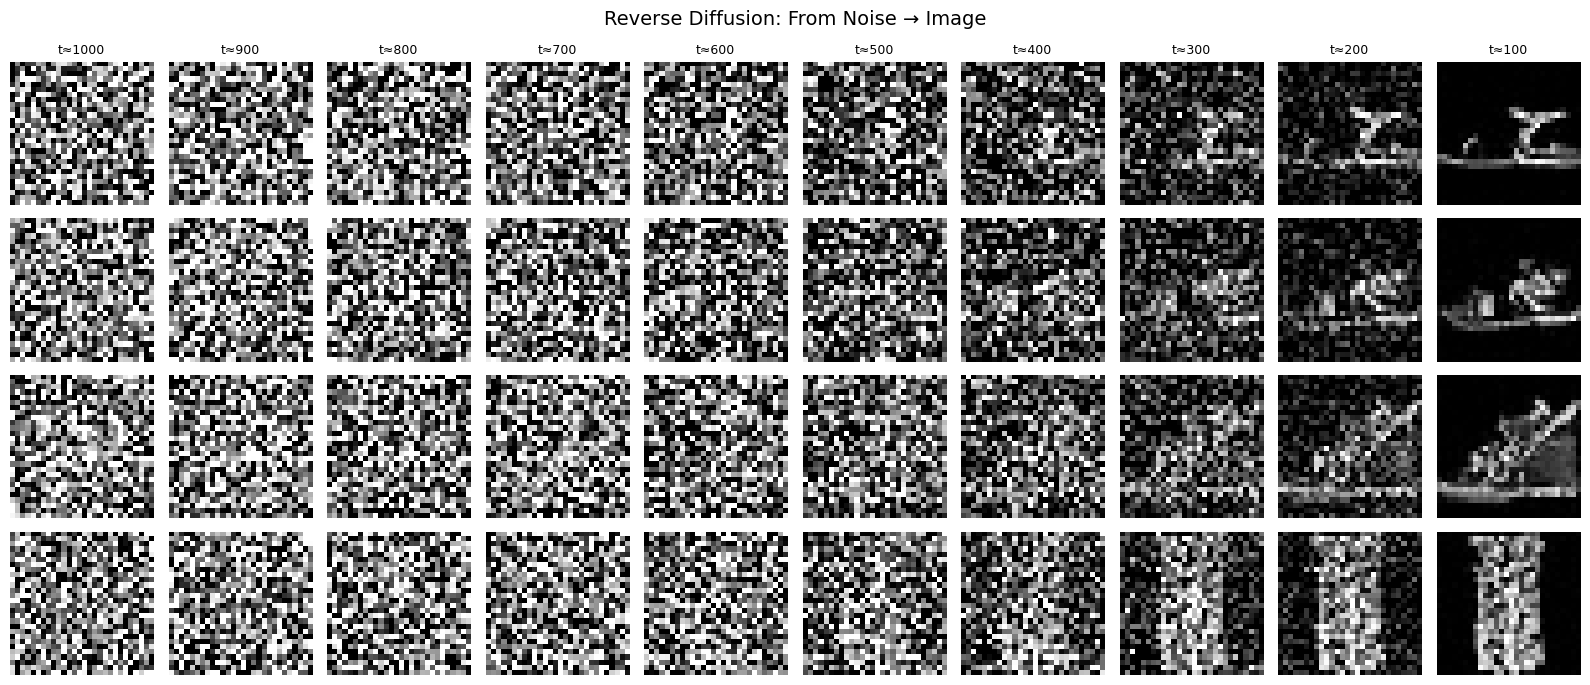

In [21]:
# Visualize the reverse diffusion (denoising) process
ema.shadow.eval()
_, intermediates = sample_ddpm(ema, n=4, return_intermediates=True)

fig, axes = plt.subplots(4, len(intermediates), figsize=(16, 7))
for row in range(4):
    for col, img in enumerate(intermediates):
        axes[row, col].imshow(((img[row, 0].cpu() + 1) / 2).clamp(0, 1), cmap='gray')
        axes[row, col].axis('off')
        if row == 0:
            step = T - col * (T // 10)
            axes[row, col].set_title(f't≈{step}', fontsize=9)
plt.suptitle('Reverse Diffusion: From Noise → Image', fontsize=14)
plt.tight_layout()
plt.show()